In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rohanharode07/webmd-drug-reviews-dataset")

print("Path to dataset files:", path)

/Users/hungnguyen/study - master IT 2024/Term 4/research/research-code/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/hungnguyen/.cache/kagglehub/datasets/rohanharode07/webmd-drug-reviews-dataset/versions/1


In [3]:
# List the head of dataset files
import os
print("Files in dataset directory:", os.listdir(path))
# Load the dataset using pandas
import pandas as pd
dataset_file = os.path.join(path, "webmd.csv")
df = pd.read_csv(dataset_file)
df.head()

Files in dataset directory: ['webmd.csv']


,Age,Condition,Date,Drug,DrugId,EaseofUse,Effectiveness,Reviews,Satisfaction,Sex,Sides,UsefulCount
0,75 or over,Stuffy Nose,9/21/2014,25dph-7.5peh,146724,5,5,I'm a retired physician and of all the meds I ...,5,Male,"Drowsiness, dizziness , dry mouth /nose/thro...",0
1,25-34,Cold Symptoms,1/13/2011,25dph-7.5peh,146724,5,5,cleared me right up even with my throat hurtin...,5,Female,"Drowsiness, dizziness , dry mouth /nose/thro...",1
2,65-74,Other,7/16/2012,warfarin (bulk) 100 % powder,144731,2,3,why did my PTINR go from a normal of 2.5 to ov...,3,Female,,0
3,75 or over,Other,9/23/2010,warfarin (bulk) 100 % powder,144731,2,2,FALLING AND DON'T REALISE IT,1,Female,,0
4,35-44,Other,1/6/2009,warfarin (bulk) 100 % powder,144731,1,1,My grandfather was prescribed this medication ...,1,Male,,1


In [ ]:
# Show the drug that has different satisfaction and effectiveness, let say d id the satisfaction - effectiveness, d = 1 low, d = 2 medium, d = 3 high
df["distance"] = df["Satisfaction"] - df["Effectiveness"]
# Order the distance
df = df.sort_values(by="distance", ascending=False)
# Show the top 10 drugs
df.head(10)

,Age,Condition,Date,Drug,DrugId,EaseofUse,Effectiveness,Reviews,Satisfaction,Sex,Sides,UsefulCount,distance
76278,75 or over,Chronic Pain,9/24/2009,ms contin,1507,1,1,,5,Male,"Nausea , vomiting , constipation , sweating...",1,4
103466,35-44,Birth Control,11/29/2008,mirena intrauterine device,20420,4,1,i love it i haven't had a period in 5 months i...,5,Female,"Pain, bleeding, or dizziness during and afte...",1,4
146650,65-74,Osteoporosis,10/20/2011,"reclast bottle, infusion",148235,5,1,I wrote a review a couple of days ago when I d...,5,Female,"Nausea , tiredness, flu -like symptoms (e.g.,...",38,4
95780,45-54,Type 2 Diabetes Mellitus,3/28/2010,metformin hcl,11285,5,1,loose bowels,5,Female,"Nausea , vomiting , stomach upset, diarrhe...",15,4
239357,75 or over,Breast Cancer that has Spread to Another Part ...,3/1/2011,arimidex,4511,5,1,"does this medicine stay in the body, helping k...",5,Female,"Hot flashes , headache , trouble sleeping , ...",0,4
123654,45-54,High Cholesterol,7/2/2013,pravastatin sodium,6989,5,1,i'm haven't been taking long enough to see a d...,5,Female,,3,4
37117,,,10/14/2008,levetiracetam,17855,5,1,,5,,"Drowsiness, dizziness , unusual tiredness, or...",0,4
49534,45-54,Pain,5/11/2013,oxycodone-acetaminophen,2796,3,1,itching all over.,5,Female,"Nausea , vomiting , constipation , lighthea...",2,4
360864,65-74,Depression,6/8/2010,celexa,8603,5,1,I have been taking Celexa for a couple of year...,5,Female,"Nausea , dry mouth , loss of appetite, tiredn...",1,4
259594,45-54,Dysfunction of Left Ventricle of Heart Without...,9/13/2011,enalapril maleate solution,6301,5,1,,5,Female,"Dizziness , lightheadedness , or weakness m...",0,4


In [12]:
#count the number of rows which has distance larger than 3
df["DrugId"][df["distance"] > 3].count()

np.int64(214)

In [ ]:
# get 10000 rows from df
df = df.sample(100000)

df.isnull().sum()

Age              0
Condition        0
Date             0
Drug             0
DrugId           0
EaseofUse        0
Effectiveness    0
Reviews          2
Satisfaction     0
Sex              0
Sides            0
UsefulCount      0
dtype: int64

In [47]:
df = df.dropna()

for col in df.columns:
    if df[col].dtype.kind == "O":
        df[col] = df[col].str.strip()

df["Reviews"] = df["Reviews"].astype(str).str.strip()

def filter_anomalies(df: pd.DataFrame, min_review_len: int = 10) -> pd.DataFrame:
    """Remove nulls and very short/uninformative reviews."""
    before = len(df)
    df = df.dropna(subset=["Reviews"]).copy()
    df = df[df["Reviews"].str.strip().str.len() >= min_review_len].copy()
    print(f"\n[3] Anomaly filter: removed {before - len(df)} rows "
          f"(null or < {min_review_len} chars).  Remaining: {len(df):,}")
    return df

def filter_anomalies_report(df: pd.DataFrame) -> pd.DataFrame:
    before = len(df)
    df_filtered = filter_anomalies(df)
    after = len(df_filtered)

    removed = before - after
    removed_pct = (removed / before) * 100 if before > 0 else 0

    print("\n[3] Anomaly Filter Summary")
    print(f"-----------------------------------")
    print(f"Rows before filtering : {before:,}")
    print(f"Rows after filtering  : {after:,}")
    print(f"Rows removed          : {removed:,}")
    print(f"Percent removed       : {removed_pct:.2f}%")
    return df_filtered

df = filter_anomalies_report(df)
len(df)


[3] Anomaly filter: removed 1200 rows (null or < 10 chars).  Remaining: 8,798

[3] Anomaly Filter Summary
-----------------------------------
Rows before filtering : 9,998
Rows after filtering  : 8,798
Rows removed          : 1,200
Percent removed       : 12.00%


8798

filter_anomalies_report(df)

In [48]:
from transformers import pipeline
from tqdm import tqdm
import torch

#list of models used in the paper
models = {
    "roberta-twitter": "cardiffnlp/twitter-roberta-base-sentiment",
    "distilbert-sst2": "distilbert-base-uncased-finetuned-sst-2-english",
    "bio-bert": "microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract"
}

# Check if MPS is available
device = 0 if torch.backends.mps.is_available() else -1
print("Using device:", "MPS GPU" if device == 0 else "CPU")

# classifier = pipeline(
#     "sentiment-analysis",
#     model="cardiffnlp/twitter-roberta-base-sentiment",
#     device=6 # GPU
# )

pipelines = {}

for name, model_name in models.items():
    pipelines[name] = pipeline(
        "sentiment-analysis",
        model=model_name,
        device=0, # change to 0 if using GPU
        truncation=True,
        padding=True,
        max_length=512  
    )
    
texts = df["Reviews"].tolist()

results = []
batch_size = 32

# for i in tqdm(range(0, len(texts), batch_size)):
#     batch = texts[i:i+batch_size]
#     outputs = classifier(batch, batch_size=batch_size)
#     results.extend(outputs)

import time

for model_name, clf in pipelines.items():
    print(f"Running {model_name}...")
    start_time = time.time()
    
    labels = []
    scores = []
    
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]
        outputs = clf(batch)
        
        for output in outputs:
            labels.append(output["label"])
            scores.append(output["score"])
    
    # Assign results back to dataframe
    df[f"{model_name}_label"] = labels
    df[f"{model_name}_score"] = scores

    print(f"{model_name} finished in {time.time() - start_time:.2f}s")

df["roberta-twitter_label_transformed"] = df["roberta-twitter_label"].map({"LABEL_0": -1, "LABEL_1": 0, "LABEL_2": 1})
df["distilbert-sst2_label_transformed"] = df["distilbert-sst2_label"].map({"POSITIVE": 1, "NEGATIVE": -1})
df["bio-bert_label_transformed"] = df["bio-bert_label"].map({"LABEL_0": 1, "LABEL_1": -1})


# save the df to a csv file
df.to_csv("3_models_results_transformed-test.csv", index=False)
df.head()



Using device: MPS GPU


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 46005.74it/s]
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 41250.69it/s]
BertForSequenceClassification LOAD REPORT from: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight           

Running roberta-twitter...


100%|██████████| 275/275 [04:35<00:00,  1.00s/it]


roberta-twitter finished in 275.44s
Running distilbert-sst2...


100%|██████████| 275/275 [02:19<00:00,  1.98it/s]


distilbert-sst2 finished in 139.12s
Running bio-bert...


100%|██████████| 275/275 [03:31<00:00,  1.30it/s]

bio-bert finished in 211.99s


,Age,Condition,Date,Drug,DrugId,EaseofUse,Effectiveness,Reviews,Satisfaction,Sex,...,UsefulCount,roberta-twitter_label,roberta-twitter_score,distilbert-sst2_label,distilbert-sst2_score,bio-bert_label,bio-bert_score,roberta-twitter_label_transformed,distilbert-sst2_label_transformed,bio-bert_label_transformed
241389,35-44,Chronic Trouble Sleeping,9/8/2009,ambien,9690,5,5,it helps me get too sleep,5,Female,...,3,LABEL_2,0.648148,NEGATIVE,0.973762,LABEL_1,0.516096,1,-1,-1
37996,65-74,Urinary Tract Infection due to E. Coli Bacteria,10/18/2014,levaquin,14492,5,5,Have long history of UTI w 3 kidneys. Resistan...,5,Female,...,2,LABEL_2,0.516249,NEGATIVE,0.986885,LABEL_1,0.555448,1,-1,-1
42869,25-34,Other,11/10/2008,azithromycin packet macrolide antibiotics,1527,3,2,Sinus infection w/ fluid on my right ear. Too...,2,Female,...,7,LABEL_0,0.729997,NEGATIVE,0.996210,LABEL_1,0.575825,-1,-1,-1
165252,,Bipolar I Disorder with Most Recent Episode Mixed,5/11/2010,"saphris tablet, sublingual",152902,4,5,i'm very very satisfied with this medication i...,5,Female,...,19,LABEL_2,0.920411,POSITIVE,0.997754,LABEL_1,0.569845,1,1,-1
277212,65-74,Other,5/17/2011,forteo pen injector,64474,5,1,Have been taking Forteo for 46 days for osteop...,1,Female,...,5,LABEL_0,0.501077,NEGATIVE,0.997077,LABEL_1,0.598713,-1,-1,-1


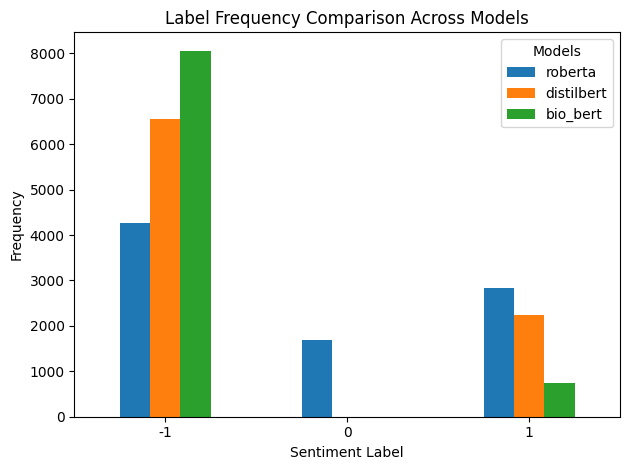

In [49]:
# Count labels for each model
roberta_counts = df["roberta-twitter_label_transformed"].value_counts()
distilbert_counts = df["distilbert-sst2_label_transformed"].value_counts()
bio_bert_counts = df["bio-bert_label_transformed"].value_counts()

# Combine into one DataFrame
label_counts = pd.DataFrame({
    "roberta": roberta_counts,
    "distilbert": distilbert_counts,
    "bio_bert": bio_bert_counts
}).fillna(0)

label_counts.plot(kind="bar")

plt.title("Label Frequency Comparison Across Models")
plt.xlabel("Sentiment Label")
plt.ylabel("Frequency")
plt.xticks(rotation=0)

plt.legend(title="Models")
plt.tight_layout()
plt.show()

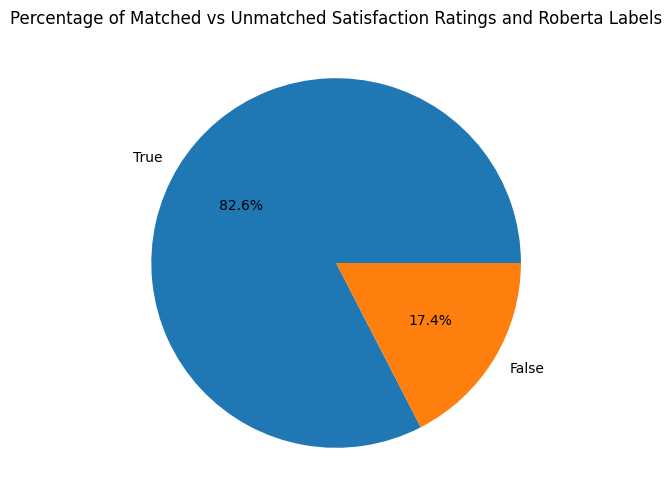

223171    It was suggested by my Dr after the death of m...
351697    I am 42 I been a a bunch on meds to lower Chol...
29674                                    made no difference
331767                                  shortness of breath
274360    Mostly effective during the day.  Minimally ef...
                                ...                        
197430    After using this drop for about a week I woke ...
254812    I have been on Errin for almost 2 weeks now. I...
13654     I have ben prescribed 80 mgss per day and they...
10746     this med gave me months of prolonged ibs also ...
216609    I found that this drug causes my BP to rise. M...
Name: Reviews, Length: 606, dtype: object


In [60]:
# compare model labels with satisfaction-derived labels

def satisfaction_to_class(rating: int) -> int:
    """Map WebMD 1–5 satisfaction to 0=Negative, 1=Neutral, 2=Positive."""
    r = int(rating)
    if r <= 2:
        return -1
    if r > 2 and r < 4:
        return 0
    if r >= 4 and r <= 5:
        return 1
    return -1

df["label_satisfaction"] = df["Satisfaction"].apply(satisfaction_to_class)

# compare like-for-like strings
df["is_same"] = df["label_satisfaction"] == df["roberta-twitter_label_transformed"]

# plot percentages using dynamic labels to avoid label-length mismatch
counts = df["is_same"].value_counts()
plt.figure(figsize=(10, 6))
plt.pie(counts.values, labels=counts.index.astype(str), autopct="%1.1f%%")
plt.title("Percentage of Matched vs Unmatched Satisfaction Ratings and Roberta Labels")
plt.show()

#print the review that is not matched
print(df[df["is_same"] == False]["Reviews"])



label_satisfaction
-1    3477
Name: count, dtype: int64


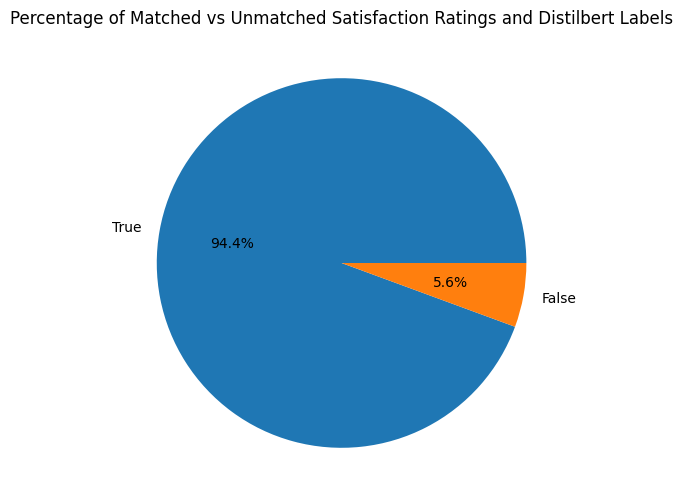

In [ ]:
# compare like-for-like strings
# remove the df["label_satisfaction"] = 0 neutral
df = df[df["label_satisfaction"] != 0]

print(df["label_satisfaction"].value_counts())
df["is_same"] = df["label_satisfaction"] == df["distilbert-sst2_label_transformed"]

# plot percentages using dynamic labels to avoid label-length mismatch
counts = df["is_same"].value_counts()
plt.figure(figsize=(10, 6))
plt.pie(counts.values, labels=counts.index.astype(str), autopct="%1.1f%%")
plt.title("Percentage of Matched vs Unmatched Satisfaction Ratings and Distilbert Labels")
plt.show()


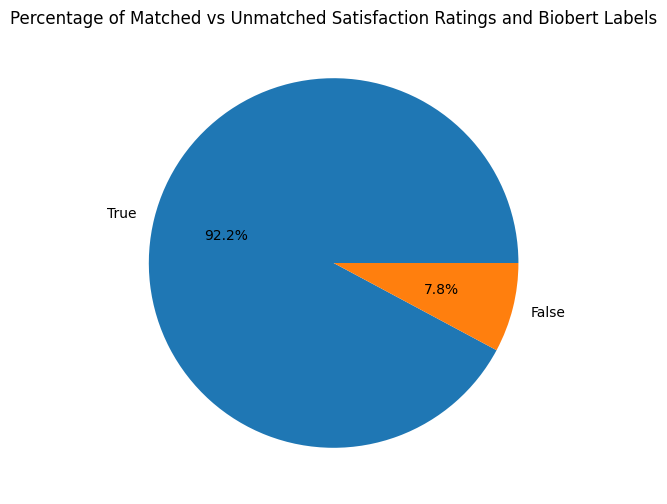

In [61]:
df["is_same"] = df["label_satisfaction"] == df["bio-bert_label_transformed"]

# plot percentages using dynamic labels to avoid label-length mismatch
counts = df["is_same"].value_counts()
plt.figure(figsize=(10, 6))
plt.pie(counts.values, labels=counts.index.astype(str), autopct="%1.1f%%")
plt.title("Percentage of Matched vs Unmatched Satisfaction Ratings and Biobert Labels")
plt.show()
